# 4.4 결측 자료

- **결측 자료(Missing Data)** 는 누락된, 있어야 하는데 없는 데이터이다
- 이러한 결측 자료는 특별한 방식으로 부호화함
- 유효 값들이 항상 양수라면, -1로 표시
- 부동소수점 값의 경우에는 NaN(not a number; 수가 아님)을 사용함
- `Numpy`는 배열에 NaN이 있는지 점검하는 `np.isnan` 함수를 제공함

In [1]:
import numpy as np
import matplotlib.pylab as plt

In [2]:
# np.isnan(): NaN 여부 확인
# NaN 여부는 np.isnan()으로 점검해야 올바른 결과를 얻을 수 있음

a = np.arange(10, dtype="float64")
a[3] = np.nan

print(f"결측값 여부(using np.isnan): {np.isnan(a[3])}")
print(f"결측값 여부(using ==): {a[3] == np.nan}")
print(f"결측값 여부(using is): {a[3] is np.nan}")

결측값 여부(using np.isnan): True
결측값 여부(using ==): False
결측값 여부(using is): False


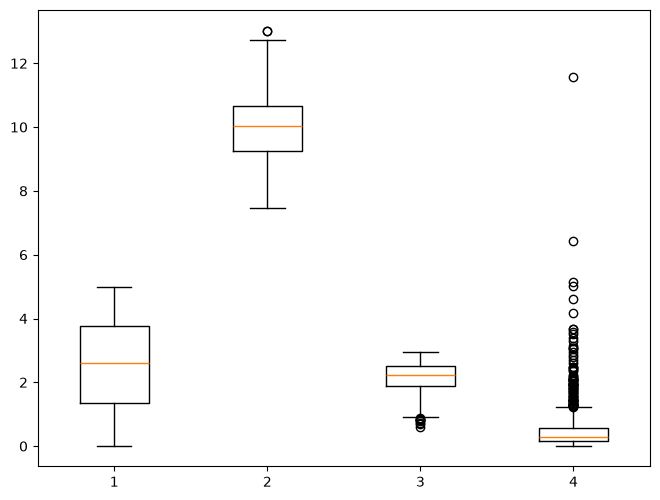

In [3]:
N = 1000
np.random.seed(73939133)
x = np.zeros((N,4))
x[:,0] = 5*np.random.random(N)
x[:,1] = np.random.normal(10,1,size=N)
x[:,2] = 3*np.random.beta(5,2,N)
x[:,3] = 0.3*np.random.lognormal(size=N)

# 시각화
plt.boxplot(x)
plt.tight_layout(pad=0, w_pad=0, h_pad=0)
# plt.savefig("missing_box_plot.png", dpi=300)
plt.show()

In [4]:
# Make 5% of the values NaN
i = np.random.randint(0,N, size=int(0.05*N))
x[i,0] = np.nan
i = np.random.randint(0,N, size=int(0.05*N))
x[i,1] = np.nan
i = np.random.randint(0,N, size=int(0.05*N))
x[i,2] = np.nan
i = np.random.randint(0,N, size=int(0.05*N))
x[i,3] = np.nan

NaNs present


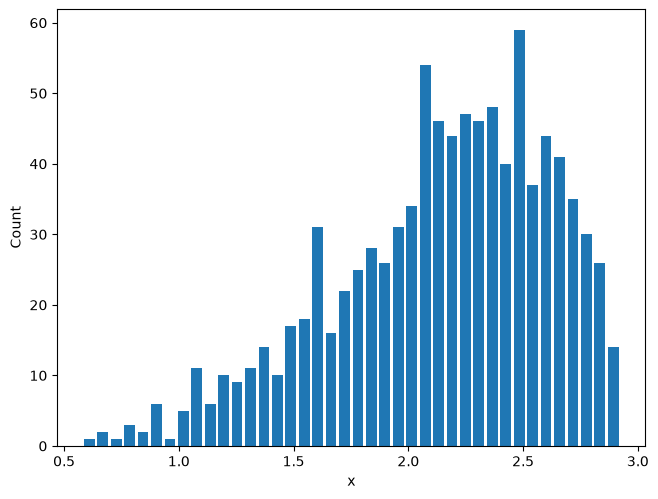

non-NaN mean, std =  2.169986269563819 0.4745140140980093
updated mean, std =  2.173269045427578 0.4629566451638146


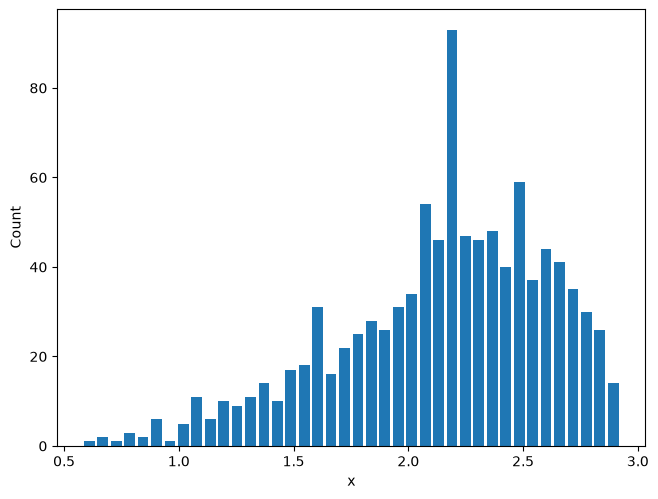

In [5]:
#  Do we have NaNs in feature 2?
if (np.isnan(x[:,2]).sum() != 0):
    print("NaNs present")
    i = np.where(np.isnan(x[:,2]) == False)
    z = x[i,2]
    mn,md,s = z.mean(), np.median(z), z.std(ddof=1)
    hh,xx = np.histogram(z, bins=40)
    plt.bar(xx[:-1],hh, width=0.8*(xx[1]-xx[0]))
    plt.xlabel("x")
    plt.ylabel("Count")
    plt.tight_layout(pad=0, w_pad=0, h_pad=0)
    # plt.savefig("missing_feature_2_plot.png", dpi=300)
    plt.show()

    i = np.where(np.isnan(x[:,2]) == True)
    x[i,2] = md  # replace w/median
    
    print("non-NaN mean, std = ", z.mean(), z.std(ddof=1))
    print("updated mean, std = ", x[:,2].mean(), x[:,2].std(ddof=1))

    hh,xx = np.histogram(x[:,2], bins=40)
    plt.bar(xx[:-1],hh, width=0.8*(xx[1]-xx[0]))
    plt.xlabel("x")
    plt.ylabel("Count")
    plt.tight_layout(pad=0, w_pad=0, h_pad=0)
    # plt.savefig("missing_feature_2_updated_plot.png", dpi=300)
    plt.show()

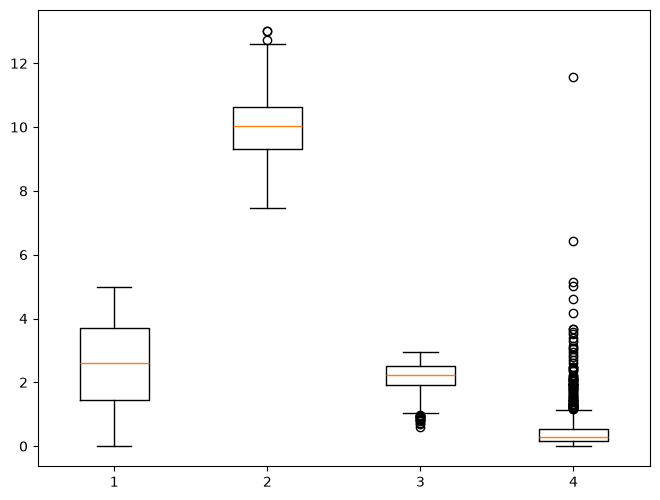

In [6]:
#  Do the same to the others
good_idx = np.where(np.isnan(x[:,0]) == False)
m = np.median(x[good_idx,0])
bad_idx = np.where(np.isnan(x[:,0]) == True)
x[bad_idx,0] = m

good_idx = np.where(np.isnan(x[:,1]) == False)
m = np.median(x[good_idx,1])
bad_idx = np.where(np.isnan(x[:,1]) == True)
x[bad_idx,1] = m

good_idx = np.where(np.isnan(x[:,3]) == False)
m = np.median(x[good_idx,3])
bad_idx = np.where(np.isnan(x[:,3]) == True)
x[bad_idx,3] = m

plt.boxplot(x)
plt.tight_layout(pad=0, w_pad=0, h_pad=0)
# plt.savefig("missing_updated_box_plot.png", dpi=300)
plt.show()

- 결측값들을 모두 제거하면 데이터 집합이 편항될 정도로 결측 자료가 크다면, 결측값들을 평균이나 중앙값을 대체하는 것이 안전함
- 평균인지 중앙값인지는 요약 통계량, 상자 그림, 히스토그램 등을 참고해야 함
- 데이터 집합에 분류명(label)이 포함되어 있다면, 분류명별로 항목들을 묶어서 평균이나 중앙값을 구해야 함
- 그렇지 않으면 개별 분류에 적합하지 않은 평균 또는 중앙값이 산출됨